# Step 8 — Altman Z-Score Comparison

The Altman Z-Score (1968) is the industry-standard formula for bankruptcy prediction:

**Z = 1.2×(Working Capital/Total Assets) + 1.4×(Retained Earnings/Total Assets) + 3.3×(EBIT/Total Assets) + 0.6×(Market Value/Total Liabilities) + 1.0×(Net Sales/Total Assets)**

- Z > 2.99 → Safe zone
- 1.81 < Z < 2.99 → Grey zone
- Z < 1.81 → Distress zone (predicted bankrupt)

This step evaluates the Altman Z-Score against the CatBoost model on the same test set (2015–2018), using identical company-year observations from the Lombardo et al. (2022) dataset.

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print('All imports successful!')

All imports successful!


In [2]:
df = pd.read_csv('../data/american_bankruptcy_dataset.csv')
df['target'] = (df['status_label'] == 'failed').astype(int)

test_df = df[df['fyear'] >= 2015].copy()
y_test = test_df['target'].values

print(f'Test set size: {len(test_df)}')
print(f'Bankrupt: {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'Alive: {(1-y_test).sum()} ({(1-y_test).mean()*100:.1f}%)')

Test set size: 12282
Bankrupt: 287 (2.3%)
Alive: 11995 (97.7%)


## Altman Z-Score Calculation

Feature mapping from the Lombardo et al. (2022) dataset:
- Working Capital = X1 (Current Assets) - X14 (Current Liabilities)
- Total Assets = X10
- Retained Earnings = X15
- EBIT = X12
- Market Value of Equity = X8
- Total Liabilities = X17
- Net Sales = X9

In [3]:
# Compute Altman Z-Score components
# Avoid division by zero
eps = 1e-10

working_capital = test_df['X1'] - test_df['X14']
total_assets    = test_df['X10'].replace(0, eps)
total_liab      = test_df['X17'].replace(0, eps)

A = working_capital      / total_assets   # Working Capital / Total Assets
B = test_df['X15']       / total_assets   # Retained Earnings / Total Assets
C = test_df['X12']       / total_assets   # EBIT / Total Assets
D = test_df['X8']        / total_liab     # Market Value / Total Liabilities
E = test_df['X9']        / total_assets   # Net Sales / Total Assets

z_scores = 1.2*A + 1.4*B + 3.3*C + 0.6*D + 1.0*E

# Predict: Z < 1.81 = bankrupt (1), else alive (0)
z_preds = (z_scores < 1.81).astype(int)

print('Z-Score distribution:')
print(f'  Mean: {z_scores.mean():.2f}')
print(f'  Min:  {z_scores.min():.2f}')
print(f'  Max:  {z_scores.max():.2f}')
print(f'  Companies predicted bankrupt: {z_preds.sum()} ({z_preds.mean()*100:.1f}%)')

Z-Score distribution:
  Mean: -4694.83
  Min:  -4934308.41
  Max:  753448.96
  Companies predicted bankrupt: 7027 (57.2%)


In [4]:
# Altman Z-Score performance
print('=== Altman Z-Score Performance (Test Set 2015-2018) ===')
print(classification_report(y_test, z_preds, target_names=['Alive', 'Failed']))

# AUC using inverted Z-score as probability (lower Z = higher risk)
z_auc = roc_auc_score(y_test, -z_scores)
print(f'AUC: {z_auc:.4f}')

=== Altman Z-Score Performance (Test Set 2015-2018) ===
              precision    recall  f1-score   support

       Alive       0.98      0.43      0.60     11995
      Failed       0.03      0.70      0.05       287

    accuracy                           0.44     12282
   macro avg       0.51      0.57      0.33     12282
weighted avg       0.96      0.44      0.59     12282

AUC: 0.5751


## CatBoost Performance (from Step 2)

In [5]:
FEATURES = ['X1','X2','X3','X4','X5','X6','X7','X8',
            'X9','X10','X11','X12','X13','X14','X15',
            'X16','X17','X18','Division']
cat_idx = [FEATURES.index('Division')]

model = CatBoostClassifier()
model.load_model('../model/catboost_bankruptcy.cbm')

test_pool = Pool(test_df[FEATURES], y_test, cat_features=cat_idx)
cb_proba  = model.predict_proba(test_pool)[:, 1]
cb_preds  = (cb_proba >= 0.4).astype(int)
cb_auc    = roc_auc_score(y_test, cb_proba)

print('=== CatBoost Performance (Test Set 2015-2018) ===')
print(classification_report(y_test, cb_preds, target_names=['Alive', 'Failed']))
print(f'AUC: {cb_auc:.4f}')

=== CatBoost Performance (Test Set 2015-2018) ===
              precision    recall  f1-score   support

       Alive       0.99      0.77      0.87     11995
      Failed       0.07      0.71      0.13       287

    accuracy                           0.77     12282
   macro avg       0.53      0.74      0.50     12282
weighted avg       0.97      0.77      0.85     12282

AUC: 0.8281


## Head-to-Head Comparison

In [6]:
summary = pd.DataFrame([
    {
        'Model': 'Altman Z-Score',
        'AUC':   round(z_auc, 4),
        'Failed Recall':    round(recall_score(y_test, z_preds, pos_label=1, zero_division=0), 3),
        'Failed Precision': round(precision_score(y_test, z_preds, pos_label=1, zero_division=0), 3),
        'Failed F1':        round(f1_score(y_test, z_preds, pos_label=1, zero_division=0), 3),
    },
    {
        'Model': 'CatBoost (threshold=0.4)',
        'AUC':   round(cb_auc, 4),
        'Failed Recall':    round(recall_score(y_test, cb_preds, pos_label=1, zero_division=0), 3),
        'Failed Precision': round(precision_score(y_test, cb_preds, pos_label=1, zero_division=0), 3),
        'Failed F1':        round(f1_score(y_test, cb_preds, pos_label=1, zero_division=0), 3),
    }
]).set_index('Model')

print(summary.to_string())

                             AUC  Failed Recall  Failed Precision  Failed F1
Model                                                                       
Altman Z-Score            0.5751          0.700             0.029      0.055
CatBoost (threshold=0.4)  0.8281          0.711             0.069      0.126


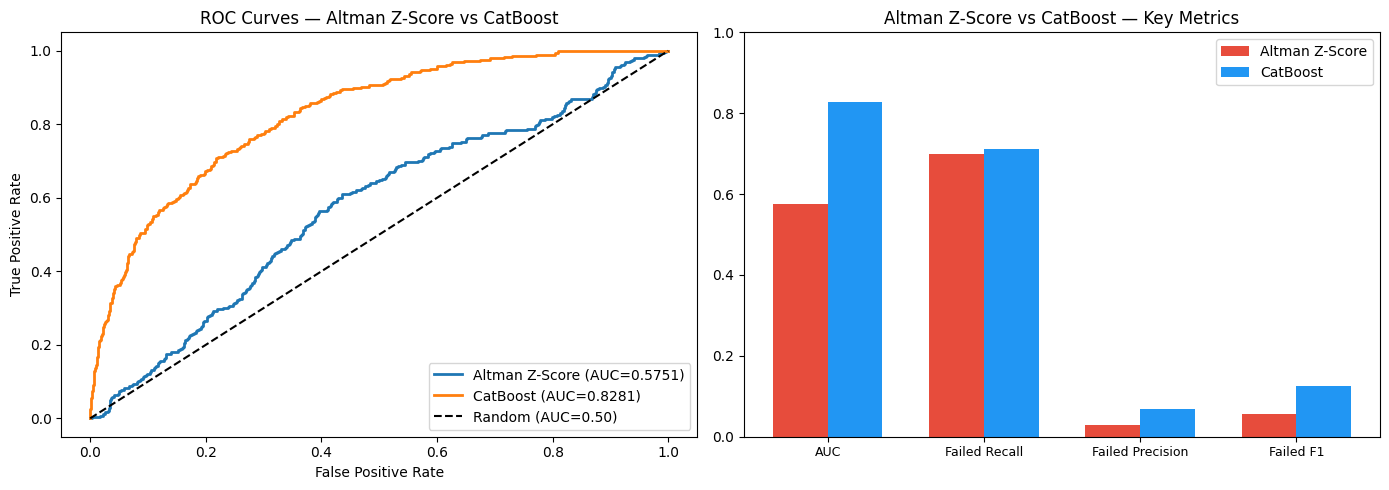

Chart saved!


In [7]:
# ROC Curve Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
for label, scores in [('Altman Z-Score', -z_scores), ('CatBoost', cb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Altman Z-Score vs CatBoost')
ax.legend()

# Bar chart comparison
ax2 = axes[1]
metrics = ['AUC', 'Failed Recall', 'Failed Precision', 'Failed F1']
x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, summary.loc['Altman Z-Score', metrics], width, label='Altman Z-Score', color='#E74C3C')
ax2.bar(x + width/2, summary.loc['CatBoost (threshold=0.4)', metrics], width, label='CatBoost', color='#2196F3')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_title('Altman Z-Score vs CatBoost — Key Metrics')
ax2.legend()

plt.tight_layout()
plt.savefig('../model/altman_vs_catboost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')